# Тест 1 — одинаково ли детектор и его симуляция откликаются на трек

## Почему обычные сравнения тут бесполезны

Распределение того, что мы видим, раскладывается на два множителя:

```
P(хиты)  =  P(хиты | трек)  ×  P(трек)
```

Первый — **отклик**: как детектор отвечает на пролёт мюона по заданной
траектории. Второй — **популяция**: какие траектории вообще приходят.
Гипотеза (a) портит второй множитель, (b) — первый.

Любое сравнение «просто распределений» видит их произведение и различить не
может. Нужно сравнение **при зафиксированном треке**.

## Физическая модель

Мюон летит быстрее света в воде и оставляет за собой конус черенковского света.
Поэтому время прихода света на модуль однозначно вычисляется по траектории:

```
t_пред(x)  =  t₀  +  [ s(x) + K · d(x) ] / c
```

* `x` — положение модуля, три координаты, известно из геометрии детектора;
* трек задаётся точкой `p₀` и единичным направлением `u`;
* `s(x) = (x − p₀)·u` — **продольная** координата: как далеко вдоль трека
  находится проекция модуля;
* `d(x) = |(x − p₀) − s·u|` — **поперечное расстояние от прямой трека до
  модуля**, в метрах. Это и есть колонка «расстояние до модуля» в таблицах ниже;
* `K = √(n² − 1) = 0.9364` при показателе преломления воды `n = 1.37`;
  множитель возникает из геометрии черенковского конуса;
* `c = 0.2998 м/нс` — скорость света в вакууме;
* `t₀` — момент, когда мюон проходит точку `p₀`.

Смысл формулы: свет рождается в точке `s − d/√(n²−1)` вдоль трека и проходит до
модуля путь `d·n/√(n²−1)`; сумма и даёт `(s + K·d)/c`.

**Времена в файлах отсчитываются от начала своего события**, поэтому `t₀` — это
величина внутри события, а не абсолютное время. Абсолютной шкале времени в BARS
группа не доверяет, и здесь она не используется.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(HERE / "src"))
import present
import tracks

present.glossary(["muatm", "exp", "скор ξ", "избыток", "полоса",
                  "остаток", "якорь", "ячейка", "IQR"])
DATA = HERE / "data"
cells = pd.read_parquet(DATA / "31_matched_cells.parquet")
bands = pd.read_parquet(DATA / "31_by_band.parquet")
sided = pd.read_parquet(DATA / "31_asymmetry.parquet")
BLUE, ORANGE, TEAL, INK, MUTED, SURFACE = (
    "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e", "#fcfcfb")
print(f"\nK = sqrt(n^2 - 1) = {tracks.K_CHERENKOV:.4f} при n = {tracks.N_WATER}")
print(f"порог «хит на треке»: {tracks.ON_TRACK_NS:.0f} нс; "
      f"минимум хитов для подгонки: {tracks.MIN_FIT_HITS}")

  muatm  —  симулированные атмосферные мюоны — фон, который мы умеем считать
    exp  —  экспериментальные данные Байкальского телескопа
 скор ξ  —  выход классификатора от 0 до 1; чем выше, тем больше событие похоже на нейтрино по
            мнению сети
избыток  —  во сколько раз доля экспериментальных событий в данной области скора больше такой же
            доли у симулированных мюонов. Единица означала бы согласие
 полоса  —  интервал скора, например 0.8–0.9
остаток  —  разность между наблюдённым и предсказанным временем прихода света на модуль, в
            наносекундах
  якорь  —  трек, подогнанный по остальным хитам события; по нему делается предсказание для
            выброшенного хита
 ячейка  —  группа хитов с одинаковой геометрией — одно и то же число хитов, струн и расстояний.
            Сравнение внутри ячейки не путает разницу отклика с разницей состава событий
    IQR  —  межквартильный размах — ширина распределения, расстояние от 25-го до 75-го
            проценти

## Как именно подгоняется трек

**Свободных параметров пять:** направление `u` (два угла), поперечное смещение
точки `p₀` (два числа — вдоль трека сдвигать бессмысленно, это та же прямая), и
`t₀`.

`t₀` в подгонке не участвует: при фиксированных `u` и `p₀` оптимальное `t₀` — это
просто среднее от `t − (s + K·d)/c`, поэтому его вычитают аналитически. Остаётся
**четыре** параметра, по которым идёт минимизация.

**Минимизируется** среднеквадратичное отклонение временных остатков подгоняемых
хитов. Заряды в саму подгонку не входят: они используются только чтобы взять
стартовую точку в зарядовом центроиде события.

**Почему минимум хитов равен семи.** Параметров пять; при пяти хитах система
определена точно и остаток тождественно нулевой, мерить нечего. Семь оставляет
хоть какие-то степени свободы.

### Три стадии, и зачем каждая

Задача **невыпуклая**, и направление связано с поперечным смещением: сетка,
частая по одному, груба по другому. Отсюда три стадии:

1. **Грубый поиск.** 500 направлений, равномерно раскиданных по сфере
   (последовательность Фибоначчи), в каждой из 27 стартовых точек — куб смещений
   ±30 м вокруг зарядового центроида. Даёт список кандидатов.
2. **Сеточное уточнение.** Пять раундов, попеременно смещение и направление, с
   сжимающимися масштабами: ±60 м и 10°, затем ±20 м и 3°, и так до ±1 м и 0.1°.
3. **Непрерывная полировка.** Симплекс-метод Нелдера — Мида по четырём
   параметрам.

**И всё это — из нескольких стартов, а не из лучшего.** Это не перестраховка:
на точном синтетическом треке кандидат с *худшей* оценкой на грубой сетке
полируется до нуля, а формально лучший застревает на 7.3 нс. Берётся лучший
итоговый результат из трёх стартов.

### Чем это проверено

Не данными. Генерируется синтетический трек, для которого время прихода на каждый
модуль вычислено точно по формуле выше; подгонка обязана его восстановить. На
30 треках разных направлений худшая невязка **0.000 нс**. Отдельно проверено, что
процедура *видит* ухудшение временного разрешения: при подмешивании 5 и 15 нс
джиттера ширина остатка растёт монотонно — иначе тест был бы слеп к тому, что
ищет.

Код: `src/tracks.py`, проверки: `tests/test_tracks.py`.

## Что такое «выброшенный хит» и как считается остаток

Процедура: **убрать один хит, подогнать трек по всем остальным, предсказать
убранный**. Остаток — это

```
Δt  =  t_наблюдённое(выброшенный)  −  t_пред(выброшенный)
```

Положительный `Δt` означает, что свет пришёл **позже**, чем предсказывает трек.

Ничто о выброшенном хите в его собственное предсказание не входит — ни в
направление, ни в `t₀`. Поэтому остаток измеряет ровно `P(хит | трек)`.

Из каждого события выбрасывается **до трёх хитов** — по одному за раз,
равномерно по времени внутри события. Поэтому в таблицах ниже строка — это один
выброшенный хит, а не событие: 175 779 остатков получены примерно из 59 тысяч
событий.

## Почему не разбиение струн пополам

Изначально планировалось делить струны кластера на две половины и предсказывать
одну по другой — якорь был бы жёстче. Но для этого нужно минимум шесть струн, а у
принятых событий **медиана три струны**: требование переживают лишь 216 из 7 752
принятых симулированных и 146 из 3 220 экспериментальных событий. Конструкция не
дотягивается до популяции, которая несёт избыток.

Исключение по одному хиту дотягивается до неё целиком. Якорь рыхлее — но
одинаково рыхлый в обеих выборках, а для сравнения нужно именно это.

## Шаг 1. Сравнение при согласованной геометрии

Просто сравнить ширину остатков нельзя: при (a) популяции различаются, и более
широкий остаток в данных объяснялся бы другим составом событий, а не откликом.

Поэтому хиты группируются в **ячейки** по трём признакам: сколько хитов в
событии, на скольких струнах, и на каком поперечном расстоянии от подогнанного
трека стоит выброшенный модуль. Внутри ячейки геометрия одинакова.

Ширина меряется через IQR, а не через среднеквадратичное отклонение: у остатков
тяжёлые хвосты, и одно выпадающее значение сдвинуло бы дисперсию. Нас интересует
не сдвиг, а **разброс**, поэтому берётся межквартильный размах.

In [2]:
view = cells.sort_values("n_exp", ascending=False).head(12)
present.show(
    view,
    {"hit_bin": "хитов в событии", "string_bin": "струн",
     "dist_bin": "расстояние от трека до модуля, м",
     "n_exp": "выброшенных хитов, exp", "n_mc": "выброшенных хитов, МК",
     "iqr_exp": "ширина остатка exp, нс", "iqr_mc": "ширина остатка МК, нс",
     "iqr_ratio": "отношение ширин",
     "tail_ratio": "отношение хвостов |Δt| > 50 нс",
     "implied_extra_sigma_ns": "недостающий разброс МК, нс"},
    rows="одна ячейка геометрии (показаны 12 самых населённых из "
         f"{len(cells)})",
    source=present.artefact_note(DATA / "31_matched_cells.parquet"),
    note="Столбцы «выброшенных хитов» — это НЕ число событий: из каждого события "
         "выбрасывается до трёх хитов по одному, и каждый даёт свою строку в "
         "исходных данных. «Недостающий разброс» — сколько случайного гауссова "
         "разброса надо добавить к временам в симуляции, чтобы её остаток стал "
         "таким же широким: sqrt(IQR²_exp − IQR²_МК) / 1.349.",
    decimals=2)
print(f"exp шире МК в {(cells.iqr_ratio > 1).sum()} ячейках из {len(cells)}")
print(f"медиана отношения ширин {cells.iqr_ratio.median():.2f}, "
      f"хвостов {cells.tail_ratio.median():.2f}")
print(f"медиана недостающего разброса {cells.implied_extra_sigma_ns.median():.1f} нс")

Строка — одна ячейка геометрии (показаны 12 самых населённых из 66).
Столбцы «выброшенных хитов» — это НЕ число событий: из каждого события выбрасывается до трёх
хитов по одному, и каждый даёт свою строку в исходных данных. «Недостающий разброс» — сколько
случайного гауссова разброса надо добавить к временам в симуляции, чтобы её остаток стал таким
же широким: sqrt(IQR²_exp − IQR²_МК) / 1.349.
Источник: стадия 31_response_compare, файл 31_matched_cells.parquet, 66 строк


хитов в событии,струн,"расстояние от трека до модуля, м","выброшенных хитов, exp","выброшенных хитов, МК","ширина остатка exp, нс","ширина остатка МК, нс",отношение ширин,отношение хвостов |Δt| > 50 нс,"недостающий разброс МК, нс"
8-9,3,15-30,8233,11709,40.520000,28.900000,1.400000,1.670000,21.060000
8-9,3,30-50,7180,9597,46.510000,32.610000,1.430000,1.520000,24.590000
8-9,3,<15,4498,5941,38.070000,30.440000,1.250000,1.720000,16.950000
10-11,3,15-30,3661,5220,43.960000,27.850000,1.580000,1.920000,25.220000
10-11,3,30-50,3648,5049,47.190000,28.270000,1.670000,1.970000,28.010000
8-9,3,50-80,2363,3169,56.800000,44.530000,1.280000,1.240000,26.140000
8-9,4,15-30,2237,2753,47.480000,37.570000,1.260000,1.410000,21.520000
8-9,4,30-50,2188,2530,57.550000,42.360000,1.360000,1.330000,28.880000
10-11,4,30-50,2027,2363,60.430000,38.170000,1.580000,1.630000,34.730000
12-14,3,30-50,2019,2738,51.460000,31.800000,1.620000,2.110000,29.990000


exp шире МК в 66 ячейках из 66
медиана отношения ширин 1.30, хвостов 1.51
медиана недостающего разброса 28.5 нс


**Два допущения в последнем столбце**, и оба стоит держать в голове. Деление на
1.349 переводит IQR в сигму только для гауссова распределения; вычитание в
квадратуре предполагает, что недостающий разброс независим и складывается с
имеющимся как дисперсии. Для оценки порядка величины это нормально, для точного
числа — нет.

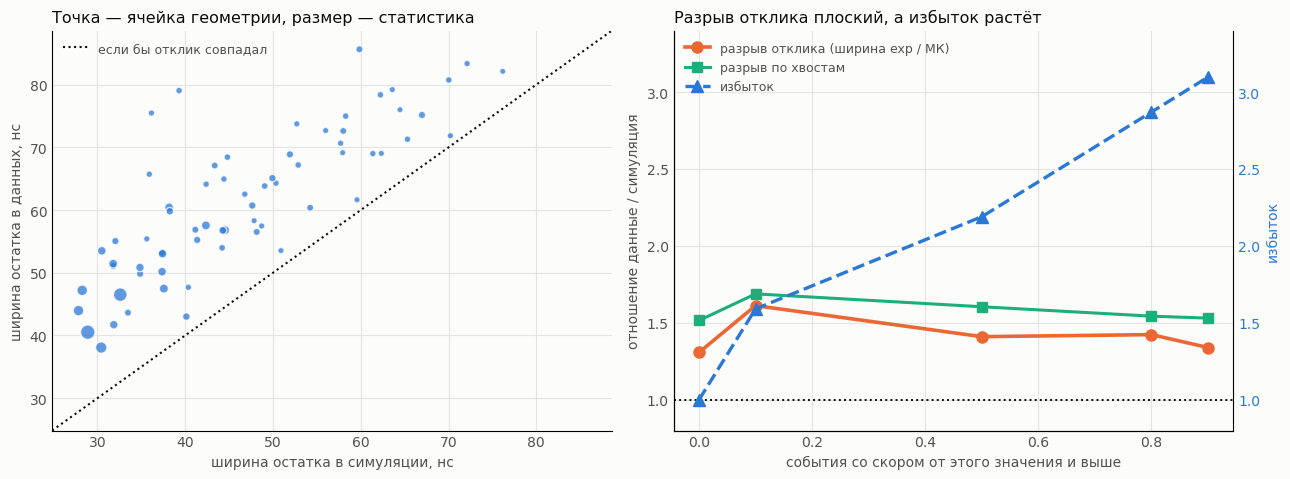

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.9))
fig.patch.set_facecolor(SURFACE)
for ax in axes:
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", lw=0.8)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
ax = axes[0]
ax.scatter(cells.iqr_mc, cells.iqr_exp,
           s=18 + 90 * (cells.n_exp / cells.n_exp.max()), color=BLUE, alpha=0.75,
           edgecolor="white", lw=1.0, zorder=3)
lim = [min(cells.iqr_mc.min(), cells.iqr_exp.min()) - 3,
       max(cells.iqr_mc.max(), cells.iqr_exp.max()) + 3]
ax.plot(lim, lim, color=INK, ls=":", lw=1.5, label="если бы отклик совпадал")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("ширина остатка в симуляции, нс", color=MUTED)
ax.set_ylabel("ширина остатка в данных, нс", color=MUTED)
ax.set_title("Точка — ячейка геометрии, размер — статистика", loc="left",
             fontsize=11.5, color=INK)
ax.legend(frameon=False, fontsize=9, labelcolor=MUTED)
ax = axes[1]
handles = [
    ax.plot(bands.band_lo, bands.iqr_ratio, "o-", color=ORANGE, lw=2.6, ms=8,
            label="разрыв отклика (ширина exp / МК)")[0],
    ax.plot(bands.band_lo, bands.tail_ratio, "s-", color=TEAL, lw=2.2, ms=7,
            label="разрыв по хвостам")[0]]
ax.axhline(1.0, color=INK, ls=":", lw=1.4)
ax.set_xlabel("события со скором от этого значения и выше", color=MUTED)
ax.set_ylabel("отношение данные / симуляция", color=MUTED)
ax.set_ylim(0.8, 3.4)
twin = ax.twinx()
handles.append(twin.plot(bands.band_lo, bands.excess_in_band, "^--", color=BLUE,
                         lw=2.4, ms=9, label="избыток")[0])
twin.set_ylabel("избыток", color=BLUE); twin.set_ylim(0.8, 3.4)
twin.tick_params(colors=BLUE, length=0); twin.spines["top"].set_visible(False)
ax.legend(handles, [h.get_label() for h in handles], frameon=False,
          fontsize=9, labelcolor=MUTED, loc="upper left")
ax.set_title("Разрыв отклика плоский, а избыток растёт", loc="left",
             fontsize=11.5, color=INK)
plt.tight_layout()
plt.savefig(HERE / "figures" / "30_response_gap.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

In [4]:
cells

,hit_bin,string_bin,dist_bin,n_exp,n_mc,iqr_exp,iqr_mc,tail_exp,tail_mc,iqr_ratio,tail_ratio,implied_extra_sigma_ns
0,8-9,3,<15,4498,5941,38.067870,30.437244,0.159627,0.092577,1.250700,1.724256,16.948436
1,8-9,3,15-30,8233,11709,40.523465,28.900734,0.196769,0.117602,1.402160,1.673180,21.057053
2,8-9,3,30-50,7180,9597,46.510382,32.606290,0.219638,0.144524,1.426424,1.519729,24.586311
3,8-9,3,50-80,2363,3169,56.804065,44.530737,0.291579,0.234459,1.275615,1.243624,26.142585
4,8-9,3,80+,1059,1026,60.726665,47.641757,0.312559,0.222222,1.274652,1.406516,27.914174
...,...,...,...,...,...,...,...,...,...,...,...,...
61,21+,5,30-50,906,840,68.878387,51.932453,0.422737,0.314286,1.326307,1.345073,33.540827
62,21+,5,50-80,335,308,83.357281,72.117350,0.528358,0.441558,1.155856,1.196576,30.988435
63,21+,6,15-30,485,363,78.380989,62.244485,0.373196,0.333333,1.259244,1.119588,35.312200
64,21+,6,30-50,768,573,85.630622,59.845873,0.524740,0.376963,1.430853,1.392018,45.401052


**Левая панель.** Все ячейки выше диагонали: при одинаковой геометрии реальные
хиты отклоняются от черенковской модели сильнее симулированных. Ни одна ячейка не
идёт в другую сторону.

Переведённое в добавочный разброс — около **29 нс**. Измеренный ранее приборный
остаток по каналам (9–11 нс,
`analysis/excess_mechanism/measure_channel_offsets.py`) объясняет малую часть.
Противоречия с тем измерением нет: там сравнивались **медианные** смещения по
каналам, а такая процедура слепа к случайному разбросу от хита к хиту.

**Правая панель.** Протокол ожидал, что при (b) разрыв будет расти вместе с
избытком. Он не растёт.

In [4]:
present.show(
    bands,
    {"band_lo": "события со скором от", "iqr_exp": "ширина остатка exp, нс",
     "iqr_mc": "ширина остатка МК, нс", "iqr_ratio": "отношение ширин",
     "tail_ratio": "отношение хвостов",
     "implied_extra_sigma_ns": "недостающий разброс МК, нс",
     "excess_in_band": "избыток в этой области"},
    rows="все события со скором от указанного значения и выше",
    source=present.artefact_note(DATA / "31_by_band.parquet"),
    note="Разрыв отклика почти не меняется (1.31 → 1.34), пока избыток растёт "
         "втрое. В нижней строке избыток равен единице — там данные и симуляция "
         "совпадают по числу событий, а отклик уже различается.",
    decimals=3)

Строка — все события со скором от указанного значения и выше.
Разрыв отклика почти не меняется (1.31 → 1.34), пока избыток растёт втрое. В нижней строке
избыток равен единице — там данные и симуляция совпадают по числу событий, а отклик уже
различается.
Источник: стадия 31_response_compare, файл 31_by_band.parquet, 5 строк


события со скором от,"ширина остатка exp, нс","ширина остатка МК, нс",отношение ширин,отношение хвостов,"недостающий разброс МК, нс",избыток в этой области
0.000000,62.143000,47.524000,1.308000,1.515000,29.682000,1.000000
0.100000,57.931000,35.945000,1.612000,1.688000,33.678000,1.591000
0.500000,44.650000,31.666000,1.410000,1.604000,23.334000,2.190000
0.800000,45.173000,31.740000,1.423000,1.543000,23.827000,2.870000
0.900000,45.670000,34.101000,1.339000,1.531000,22.519000,3.097000


## Шаг 2. Каскады или калибровка? Проверка на односторонность

Модель описывает свет **голого трека** под черенковским углом. Но мюон излучает
стохастические каскады — тормозное излучение, рождение пар, фотоядерные
взаимодействия, — и их свет идёт сферическим фронтом из точки, а не конусом от
прямой. Симуляция их воспроизводит, но если она ошибается в их частоте или
яркости, ширина остатка разойдётся **без всякой ошибки временного разрешения**.

Это различимо. Каскадный и рассеянный свет может приходить только **позже**
прямого черенковского фронта — обогнать его нельзя. Значит:

* **каскады или рассеяние** → односторонний избыток на поздней стороне;
* **ошибка калибровки или разрешения** → симметричный избыток.

In [5]:
present.show(
    sided.sort_values("n_exp", ascending=False).head(10),
    {"hit_bin": "хитов", "string_bin": "струн", "dist_bin": "расстояние, м",
     "n_exp": "выброшенных хитов, exp",
     "early_ratio": "во сколько шире ранняя сторона",
     "late_ratio": "во сколько шире поздняя сторона",
     "early_tail_ratio": "хвост раньше −50 нс",
     "late_tail_ratio": "хвост позже +50 нс",
     "median_shift_ns": "сдвиг медианы exp − МК, нс"},
    rows="одна ячейка геометрии (10 самых населённых)",
    source=present.artefact_note(DATA / "31_asymmetry.parquet"),
    note="Стороны меряются от собственной медианы ячейки, чтобы общий сдвиг не "
         "подмешивался в ширину. Δt > 0 значит «свет пришёл позже, чем "
         "предсказывает трек».",
    decimals=2)
print(f"медианы по {len(sided)} ячейкам: ранняя сторона ×"
      f"{sided.early_ratio.median():.2f}, поздняя ×{sided.late_ratio.median():.2f}")
print(f"хвосты: раньше −50 нс ×{sided.early_tail_ratio.median():.2f}, "
      f"позже +50 нс ×{sided.late_tail_ratio.median():.2f}")
print(f"сдвиг медианы: {sided.median_shift_ns.median():.1f} нс")

Строка — одна ячейка геометрии (10 самых населённых).
Стороны меряются от собственной медианы ячейки, чтобы общий сдвиг не подмешивался в ширину. Δt >
0 значит «свет пришёл позже, чем предсказывает трек».
Источник: стадия 31_response_compare, файл 31_asymmetry.parquet, 66 строк


хитов,струн,"расстояние, м","выброшенных хитов, exp",во сколько шире ранняя сторона,во сколько шире поздняя сторона,хвост раньше −50 нс,хвост позже +50 нс,"сдвиг медианы exp − МК, нс"
8-9,3,15-30,8233.000000,1.440000,1.370000,1.600000,1.770000,-2.290000
8-9,3,30-50,7180.000000,1.530000,1.320000,1.470000,1.650000,-4.170000
8-9,3,<15,4498.000000,1.260000,1.240000,1.910000,1.640000,-0.410000
10-11,3,15-30,3661.000000,1.600000,1.560000,1.770000,2.150000,-3.730000
10-11,3,30-50,3648.000000,1.970000,1.410000,2.090000,1.740000,-6.340000
8-9,3,50-80,2363.000000,1.180000,1.400000,1.200000,1.380000,-5.160000
8-9,4,15-30,2237.000000,1.240000,1.280000,1.390000,1.430000,-0.630000
8-9,4,30-50,2188.000000,1.370000,1.350000,1.420000,1.180000,-6.830000
10-11,4,30-50,2027.000000,1.740000,1.440000,1.920000,1.350000,-5.700000
12-14,3,30-50,2019.000000,1.700000,1.520000,2.080000,2.160000,-7.010000


медианы по 66 ячейкам: ранняя сторона ×1.29, поздняя ×1.37
хвосты: раньше −50 нс ×1.67, позже +50 нс ×1.39
сдвиг медианы: -6.3 нс


**Избыток симметричен**: ранняя сторона шире в 1.29 раза, поздняя в 1.37.
Хвост раньше −50 нс усилен даже сильнее, чем поздний (1.67 против 1.39). Чисто
каскадное объяснение дало бы обратную картину.

**Но исключить каскады этим нельзя**, и вот почему. `t₀` подгоняется по якорным
хитам. Лишний поздний свет **на них** утащит `t₀` вперёд, и остаток выброшенного
хита сдвинется в раннюю сторону — то есть односторонняя причина способна
притвориться симметричным разбросом. Наблюдаемый сдвиг медианы, −6.3 нс, как раз
в эту сторону и указывает на то, что такой механизм отчасти работает. Но он мал
по сравнению с разницей ширин.

Честная формулировка: симметричность **ослабляет** каскадное объяснение, но не
закрывает его. Чтобы закрыть, нужна отдельная проверка — например, сравнить
остатки у ярких и тусклых событий, поскольку каскады сильно коррелируют с
энерговыделением.

## Что установлено и чего нет

**Отклик детектора смоделирован неверно.** Все 66 ячеек в одну сторону — объяснить
это остаточной разницей составов неудобно. Симуляции не хватает около 29 нс
временного разброса, и он выглядит симметричным.

**Плоский профиль сам по себе (b) не снимает.** Доля принятых равна 3.4 × 10⁻⁴ —
избыток есть отношение малых чисел в хвосте. Равномерное ухудшение, сдвигающее
доли процента событий, увеличивает хвостовую скорость в разы, не трогая массу, и
дало бы ровно такой плоский профиль. Это проверяется прямо в тесте 3.

**Оговорки.** Согласование по *наблюдаемой* геометрии не гарантирует согласования
**истинных** треков. Расстояние до модуля берётся от подогнанного трека, то есть
несёт долю того качества подгонки, которое призвано контролировать. Перевод IQR в
сигму предполагает гауссовость, вычитание в квадратуре — независимость. И
каскадное объяснение ослаблено, но не исключено.

**Что дальше.** Тест 3 (`40_jitter.ipynb`) добавляет измеренные 29 нс в симуляцию
и смотрит, сколько избытка при этом возникает.